In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load clean dataset
df = pd.read_csv('../data/pulsealert_clean.csv')

# Split features and target
X = df.drop('hospital_death', axis=1)
y = df['hospital_death']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nDeath rate: {round(y.mean()*100, 2)}%")
print("Data loaded ✅")

Features shape: (91713, 65)
Target shape: (91713,)

Class distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64

Death rate: 8.63%
Data loaded ✅


In [2]:
# Split data - stratified to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # important - keeps same death ratio in train and test
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Apply SMOTE to training data only (never on test data)
print("\nApplying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training set shape: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print("SMOTE applied ✅")

Training set: (73370, 65)
Test set: (18343, 65)

Training class distribution:
hospital_death
0    67038
1     6332
Name: count, dtype: int64

Test class distribution:
hospital_death
0    16760
1     1583
Name: count, dtype: int64

Applying SMOTE to handle class imbalance...

After SMOTE:
Training set shape: (134076, 65)
Class distribution after SMOTE:
hospital_death
1    67038
0    67038
Name: count, dtype: int64
SMOTE applied ✅


In [3]:
# Model 1 - Logistic Regression (Baseline)
print("Training Logistic Regression...")

# Scale features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train_smote)

# Predictions
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr_model.predict(X_test_scaled)

# Metrics
lr_auc = roc_auc_score(y_test, lr_pred_proba)

print(f"\nLogistic Regression Results:")
print(f"AUC-ROC: {round(lr_auc, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Survived', 'Died']))
print("Logistic Regression DONE ✅")

Training Logistic Regression...

Logistic Regression Results:
AUC-ROC: 0.8401

Classification Report:
              precision    recall  f1-score   support

    Survived       0.97      0.83      0.89     16760
        Died       0.27      0.69      0.39      1583

    accuracy                           0.82     18343
   macro avg       0.62      0.76      0.64     18343
weighted avg       0.91      0.82      0.85     18343

Logistic Regression DONE ✅


In [4]:
# Model 2 - Random Forest
print("Training Random Forest...")
print("(This will take 3-5 minutes, please wait...)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # use all CPU cores
)
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

# Metrics
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"\nRandom Forest Results:")
print(f"AUC-ROC: {round(rf_auc, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Survived', 'Died']))
print("Random Forest DONE ✅")

Training Random Forest...
(This will take 3-5 minutes, please wait...)

Random Forest Results:
AUC-ROC: 0.8736

Classification Report:
              precision    recall  f1-score   support

    Survived       0.96      0.91      0.93     16760
        Died       0.38      0.59      0.46      1583

    accuracy                           0.88     18343
   macro avg       0.67      0.75      0.70     18343
weighted avg       0.91      0.88      0.89     18343

Random Forest DONE ✅


In [5]:
# Model 3 - XGBoost (Final Model)
print("Training XGBoost...")
print("(This will take 2-3 minutes, please wait...)")

# Calculate scale_pos_weight for class imbalance
# = number of negative cases / number of positive cases
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"scale_pos_weight: {round(scale_pos_weight, 2)}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    n_jobs=-1
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Predictions
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

# Metrics
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"\nXGBoost Results:")
print(f"AUC-ROC: {round(xgb_auc, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Survived', 'Died']))
print("XGBoost DONE ✅")

Training XGBoost...
(This will take 2-3 minutes, please wait...)
scale_pos_weight: 10.59
[0]	validation_0-auc:0.82719
[50]	validation_0-auc:0.87171
[100]	validation_0-auc:0.87939
[150]	validation_0-auc:0.88292
[200]	validation_0-auc:0.88511
[250]	validation_0-auc:0.88624
[299]	validation_0-auc:0.88692

XGBoost Results:
AUC-ROC: 0.8871

Classification Report:
              precision    recall  f1-score   support

    Survived       0.98      0.82      0.89     16760
        Died       0.29      0.78      0.43      1583

    accuracy                           0.82     18343
   macro avg       0.63      0.80      0.66     18343
weighted avg       0.92      0.82      0.85     18343

XGBoost DONE ✅


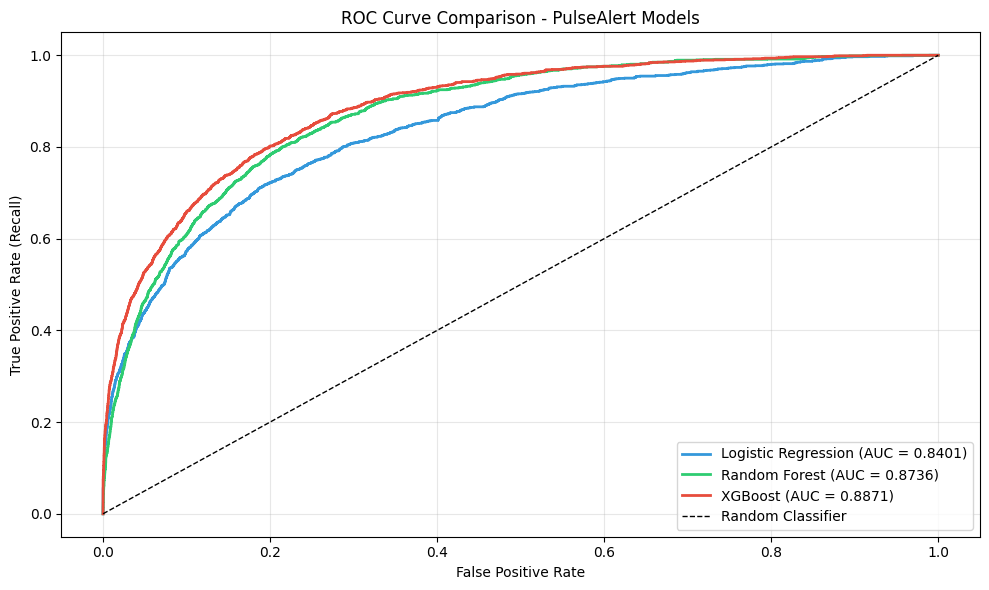

Saving models...
All models saved ✅

Notebook 03 - Model Training COMPLETE ✅

Final Summary:
  Logistic Regression AUC: 0.8401
  Random Forest AUC:       0.8736
  XGBoost AUC:             0.8871 ← Production Model
  XGBoost Recall:          0.78 (catching 78% of deaths)


In [6]:
# Plot ROC curves for all 3 models
plt.figure(figsize=(10, 6))

models = {
    'Logistic Regression': lr_pred_proba,
    'Random Forest': rf_pred_proba,
    'XGBoost': xgb_pred_proba
}

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, proba), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison - PulseAlert Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save all models
print("Saving models...")
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Save test data for evaluation notebook
np.save('../data/X_test.npy', X_test.values)
np.save('../data/y_test.npy', y_test.values)
np.save('../data/X_test_scaled.npy', X_test_scaled)
joblib.dump(X_test.columns.tolist(), '../data/feature_names.pkl')

print("All models saved ✅")
print("\nNotebook 03 - Model Training COMPLETE ✅")
print("\nFinal Summary:")
print(f"  Logistic Regression AUC: 0.8401")
print(f"  Random Forest AUC:       0.8736")
print(f"  XGBoost AUC:             0.8871 ← Production Model")
print(f"  XGBoost Recall:          0.78 (catching 78% of deaths)")